# train an agent to play Ms. Pac-Man

**Choose three numbers. Run the notebook. Watch what the agent learns.**

The agent sees the game screen, chooses a move, and receives a reward from the game.
A neural network learns a value for each move through trial and error.

1. Open this notebook in Jupyter, VS Code, or Google Colab. In Colab, select **Runtime → Change runtime type → T4 GPU** if available.
2. Choose your three settings in the next cell.
3. Choose **Run All** (Colab: **Runtime → Run all**). Setup runs automatically. Local gameplay samples open above VS Code in a floating player at **4× speed**; a copy also appears inline.
4. Compare the five before/after scores and save your results.

If using Claude Code or Codex, ask it to run this notebook. The code tells it to ask you for your three choices before training.

A short run checks that everything works. Learning useful Atari behavior can take much longer; more episodes do not guarantee better play.

## 1. your three choices

| Setting | Meaning | Starting point |
|---|---|---|
| **Exploration** | Fraction of training moves chosen randomly. `0.20` means 20%. | `0.20` |
| **Episodes** | How many games to train on. Each game ends at game over or a fixed time limit. | `100` |
| **Learning rate** | How much the network changes at each update. | `0.0001` |

Change only the three numbers below. Try `5` episodes for a first check, then a longer run.
For this experiment, exploration stays **constant** so its meaning is easy to compare across runs.
The short replay warm-up uses random moves before learning starts.

In [86]:
# AI ASSISTANT INSTRUCTION:
# Before running training, ask the student:
# "Which exploration rate (0 to 1), number of episodes (positive whole number),
# and learning rate (greater than 0 and at most 1) do you want to use?"
# Explain the three choices briefly. Wait for their answer, then edit ONLY
# these three values. If they already chose values in this conversation,
# use those choices without asking again. Do not silently choose for them.
# The remaining cells are ready to run without student edits.

EXPLORATION = 0.09
EPISODES = 1000
LEARNING_RATE = 0.0001

### check the choices

These checks catch typos before a long experiment starts. They do not change your settings.

In [87]:
import math
assert (
    isinstance(EXPLORATION, (int, float))
    and not isinstance(EXPLORATION, bool)
    and math.isfinite(EXPLORATION) and 0 <= EXPLORATION <= 1
), "Exploration must be between 0 and 1."
assert (
    isinstance(EPISODES, int) and not isinstance(EPISODES, bool) and EPISODES > 0
), "Episodes must be a positive whole number."
assert (
    isinstance(LEARNING_RATE, (int, float))
    and not isinstance(LEARNING_RATE, bool)
    and math.isfinite(LEARNING_RATE) and 0 < LEARNING_RATE <= 1
), "Learning rate must be greater than 0 and at most 1."
print(f"Your experiment: {EXPLORATION:.0%} exploration, {EPISODES} episodes, learning rate {LEARNING_RATE:g}.")

Your experiment: 9% exploration, 1000 episodes, learning rate 0.0001.


## 2. automatic setup

Run this once per fresh session. It installs missing packages into the notebook's Python environment.
Python 3.11–3.13 is recommended. No separate game download is needed. For local popup playback, keep `pacman_player.py` next to this notebook and use a Python kernel with Tk (the local `py313` kernel supports it). Colab and machines without a desktop keep the fast inline preview.
If a package was already imported before an upgrade, restart the kernel and choose Run All again.

In [88]:
%pip -q install "torch>=2.6,<3" "gymnasium==1.3.0" "ale-py==0.11.2" "opencv-python-headless==4.14.0.94" "numpy>=2,<3" "matplotlib>=3.9,<4" "Pillow>=10,<13"

### load the tools

Gymnasium runs the game, PyTorch learns from its screens, and Pillow saves gameplay. This cell also prints the actual Python and package versions, so runs can be compared.

In [89]:
import csv
import json
import platform
import random
import shutil
import time
from collections import deque
from datetime import datetime
from pathlib import Path
from importlib.metadata import version

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from PIL import Image as PILImage
from IPython.display import Image, FileLink, display

gym.register_envs(ale_py)
# Keep CPU thread overhead manageable on laptops.
torch.set_num_threads(min(4, torch.get_num_threads()))


VERSIONS = {p: version(p) for p in ['torch', 'gymnasium', 'ale-py', 'opencv-python-headless', 'numpy', 'matplotlib', 'Pillow']}
print(f"Python {platform.python_version()} | {platform.platform()}")
print(VERSIONS)

Python 3.13.15 | Linux-6.6.122+-x86_64-with-glibc2.39
{'torch': '2.11.0+cu128', 'gymnasium': '1.3.0', 'ale-py': '0.11.2', 'opencv-python-headless': '4.14.0.94', 'numpy': '2.1.3', 'matplotlib': '3.10.0', 'Pillow': '11.3.0'}


### fixed experiment settings

These values keep experiments comparable. One **decision** advances four game frames. The agent remembers 5,000 past decisions and learns from 32 at a time. The first 1,000 decisions collect experience; after that, learning happens every four decisions. You only need to edit the three choices in section 1.

In [90]:
# Fixed classroom settings. Students only need the three choices above.
SEED = 42
MAX_STEPS = 3000          # Agent decisions per game, about 200 seconds of game time.
FRAME_SKIP = 4           # Four emulator frames per agent decision, applied once.
REPLAY_CAPACITY = 5000   # About 168 MiB of pixel data, allocated gradually.
BATCH_SIZE = 32
WARMUP_STEPS = 1000      # Random-action collection before any weight updates.
TRAIN_EVERY = 4          # One update every four training decisions.
TARGET_EVERY = 1000      # Copy learned weights to target every 1,000 decisions.
GAMMA = 0.99             # How much future rewards count.
DEMO_EVERY = 25          # Episodes between gameplay demonstrations.
EVAL_SEEDS = [101, 202, 303, 404, 505]
EVAL_EXPLORATION = 0.05  # Identical before/after; independent of training choice.


### faster sample playback

Samples play **4× faster**: 20 seconds of game time takes about five seconds to watch. We save every fourth preview frame and keep a normal display interval, avoiding tiny GIF delays that viewers often clamp. This only changes the recording and playback; every game decision still runs normally.

Local samples open automatically in an **always-on-top popup** with Pause, Replay, and a pin toggle. Each sample plays exactly twice and stops on its final frame. Replay starts two more plays. Closing the popup leaves training running. Set `SHOW_POPUPS = False` for inline playback only.

In [91]:
PREVIEW_SPEED = 4
PREVIEW_PLAYS = 2
SHOW_POPUPS = True
PREVIEW_SECONDS = 20
PREVIEW_STRIDE = PREVIEW_SPEED
PREVIEW_DECISIONS = round(PREVIEW_SECONDS * 60 / FRAME_SKIP)
PREVIEW_FRAME_MS = round(1000 * FRAME_SKIP / 60)

## 3. the game and the learning rule

The network sees **four grayscale 84 × 84 screens** so it can infer movement.
Its outputs are estimated future rewards for the available moves, not probabilities.

The agent keeps past experiences in a small replay memory. It samples them to update the network.
A second, slower-changing network supplies the learning target:

**target = reward + discounted value of the next screen**

At game over, there is no future reward. At a time limit, the game could have continued, so we keep the future-value term.
Learning uses rewards clipped to −1 through +1; every score you see is the **original game score**.
The implementation below is ready to use. You do not need to edit it.

### 3a. turn game screens into observations

Start Ms. Pac-Man, reduce each screen to 84 × 84 grayscale pixels, and stack four screens. A single image shows position; a short sequence also reveals movement. Reset starts with four copies of the new game screen.

In [92]:
def make_env():
    env = gym.make("ALE/MsPacman-v5", frameskip=1,
                   repeat_action_probability=0.25, render_mode="rgb_array")
    env = gym.wrappers.AtariPreprocessing(
        env, noop_max=30, frame_skip=FRAME_SKIP, screen_size=84,
        terminal_on_life_loss=False, grayscale_obs=True, scale_obs=False)
    env = gym.wrappers.FrameStackObservation(env, stack_size=4, padding_type="reset")
    return gym.wrappers.TimeLimit(env, max_episode_steps=MAX_STEPS)

### 3b. estimate the value of each move

The convolution layers look for patterns in the screens. The final layer produces one number per move: its estimated future reward. `forward` scales pixel values from 0–255 to 0–1 before using them.

In [93]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        # Read visual patterns, then produce one value per available move.
        self.layers = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(), nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, n_actions))

    def forward(self, screens):
        return self.layers(screens.float() / 255.0)

### 3c. remember past experience

Each memory stores the screen stack, move, reward, next screen, and whether the game ended. Random batches mix experiences from different moments. Consecutive stacks share three frames, so we only store the one new frame to save memory.

In [94]:
class ReplayMemory:
    def __init__(self, capacity):
        self.items = deque(maxlen=capacity)

    def add(self, obs, action, reward, next_obs, terminated, truncated):
        # The next stack is [obs[1], obs[2], obs[3], new_frame].
        # Store five frames instead of two overlapping four-frame stacks.
        self.items.append((np.array(obs, dtype=np.uint8, copy=True), action,
                           float(np.clip(reward, -1, 1)),
                           np.array(next_obs[-1], dtype=np.uint8, copy=True),
                           bool(terminated), bool(truncated)))

    def sample(self, size, rng):
        batch = rng.sample(list(self.items), size)
        obs, actions, rewards, last_frames, ended, truncated = zip(*batch)
        obs = np.stack(obs)
        next_obs = np.concatenate([obs[:, 1:], np.stack(last_frames)[:, None]], axis=1)
        return obs, np.array(actions), np.array(rewards, dtype=np.float32), next_obs, np.array(ended), np.array(truncated)

    def __len__(self):
        return len(self.items)

### 3d. choose a move

With probability `epsilon`, try a random move (**explore**). Otherwise choose the move with the highest predicted value (**exploit**). Choosing a move does not update the network.

In [95]:
@torch.no_grad()
def choose_action(model, obs, epsilon, rng, n_actions):
    if rng.random() < epsilon:
        return rng.randrange(n_actions)
    device = next(model.parameters()).device
    screens = torch.as_tensor(np.asarray(obs), device=device).unsqueeze(0)
    return int(model(screens).argmax(dim=1).item())

### 3e. learn from a batch

1. Predict the value of each remembered move.
2. Build a target from its reward plus the next screen’s estimated value.
3. Measure the prediction error and adjust the network.

The target network changes less often to give learning a steadier reference. True game over removes future reward; reaching the time limit does not.

In [96]:
def learn(model, target, optimizer, batch):
    device = next(model.parameters()).device
    obs, actions, rewards, next_obs, ended, truncated = [torch.as_tensor(x, device=device) for x in batch]
    # 1. What value did the network predict for the move we took?
    values = model(obs).gather(1, actions.long().unsqueeze(1)).squeeze(1)
    # 2. What target does the observed reward suggest?
    with torch.no_grad():
        # Mask true termination only. A time limit still allows bootstrapping.
        targets = rewards + GAMMA * (~ended).float() * target(next_obs).max(dim=1).values
    # 3. Reduce the gap between prediction and target.
    loss = nn.functional.smooth_l1_loss(values, targets)
    if not torch.isfinite(loss):
        raise RuntimeError("Loss became non-finite. Start a new run with a smaller learning rate.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 10.0, error_if_nonfinite=True)
    optimizer.step()
    return float(loss.item())

### 3f. select working hardware

Try CUDA, Apple MPS, then CPU. A real batch tests prediction, backward pass, and a weight update before we commit to that device.

In [97]:
def select_device(n_actions):
    candidates = []
    if torch.cuda.is_available():
        candidates.append("cuda")
    if torch.backends.mps.is_available():
        candidates.append("mps")
    candidates.append("cpu")
    for candidate in candidates:
        try:
            # Test the actual network, minibatch, backward pass, and optimizer.
            probe = DQN(n_actions).to(candidate)
            optimizer = torch.optim.Adam(probe.parameters(), lr=LEARNING_RATE)
            screens = np.zeros((BATCH_SIZE, 4, 84, 84), dtype=np.uint8)
            batch = (screens, np.zeros(BATCH_SIZE, dtype=np.int64),
                     np.ones(BATCH_SIZE, dtype=np.float32), screens,
                     np.zeros(BATCH_SIZE, dtype=bool), np.zeros(BATCH_SIZE, dtype=bool))
            learn(probe, probe, optimizer, batch)
            print(f"Using {candidate.upper()}; training-batch check passed.")
            return torch.device(candidate)
        except RuntimeError as error:
            if candidate == "cpu":
                raise
            print(f"{candidate.upper()} check failed ({error}). Trying the next device.")

### check the first screen

Create the game, check the four-screen stack, and show the available joystick moves. If this cell succeeds, the game and learning hardware are ready.

Using CUDA; training-batch check passed.
Available moves: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']


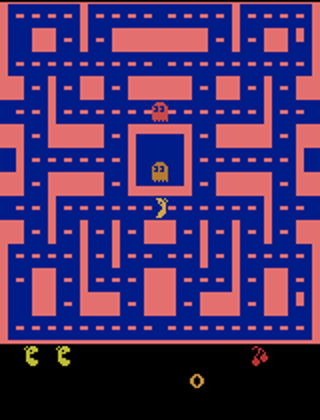

Replay pixel budget: 168 MiB, plus model and batch memory.


In [98]:
probe_env = make_env()
try:
    probe_obs, _ = probe_env.reset(seed=SEED)
    assert probe_obs.shape == (4, 84, 84) and probe_obs.dtype == np.uint8
    assert all(np.array_equal(probe_obs[0], frame) for frame in probe_obs)
    N_ACTIONS = int(probe_env.action_space.n)
    DEVICE = select_device(N_ACTIONS)
    print("Available moves:", probe_env.unwrapped.get_action_meanings())
    display(PILImage.fromarray(probe_env.render()).resize((320, 420)))
finally:
    probe_env.close()
print(f"Replay pixel budget: {REPLAY_CAPACITY * 5 * 84 * 84 / 2**20:.0f} MiB, plus model and batch memory.")

## 4. gameplay, scores, and saved results

Evaluation uses a separate game environment and the same five seeds before and after training.
It uses 5% random moves in both cases. Evaluation never changes the network or training memory.
The baseline is an **untrained network**, not a random-action agent.

GIFs show the first 20 seconds at most, compressed to about five seconds at 4× speed; the reported score covers the entire evaluated game, up to the fixed time limit.

### 4a. score complete games and record a short sample

All evaluation games run at full computing speed, with no waiting for playback. We record a short excerpt, but add rewards for the **entire game**. For the final preview we keep the excerpt from the game with the highest full-game score.

In [99]:
def evaluate(model, seeds, gif_path=None, record_best=False):
    env = make_env()
    scores, lengths, capped = [], [], []
    best_score, chosen_frames = -float("inf"), []
    was_training = model.training
    model.eval()
    try:
        for index, seed in enumerate(seeds):
            rng = random.Random(seed + 10000)
            obs, _ = env.reset(seed=seed)
            total, frames = 0.0, []
            capture = gif_path is not None and (record_best or index == 0)
            for step in range(MAX_STEPS):
                if capture and step < PREVIEW_DECISIONS and step % PREVIEW_STRIDE == 0:
                    frames.append(PILImage.fromarray(env.render()).copy())
                action = choose_action(model, obs, EVAL_EXPLORATION, rng, N_ACTIONS)
                obs, reward, ended, truncated, _ = env.step(action)
                total += reward
                if ended or truncated:
                    break
            scores.append(float(total))
            lengths.append(step + 1)
            capped.append(bool(truncated))
            if capture and (not record_best or total > best_score):
                chosen_frames, best_score = frames, total
    finally:
        env.close()
        model.train(was_training)
    if gif_path is not None and chosen_frames:
        chosen_frames[0].save(gif_path, save_all=True, append_images=chosen_frames[1:],
                              duration=PREVIEW_FRAME_MS, loop=PREVIEW_PLAYS - 1)
    return {"seeds": list(seeds), "scores": scores, "mean": float(np.mean(scores)),
            "steps": lengths, "time_limited": capped}

### 4b. show the sample

Always keep a playable GIF in the notebook. Both the inline GIF and the popup play exactly twice. When a local desktop and Tk are available, the separate floating player does not block the next learning update.

In [100]:
def show_sample(gif_path, label):
    """Display a recorded excerpt inline and, locally, above the notebook."""
    print(f"{label} | {PREVIEW_SPEED}× playback | {PREVIEW_PLAYS} plays | first {PREVIEW_SECONDS}s of game time")
    display(Image(filename=str(gif_path)))
    if not SHOW_POPUPS:
        return
    try:
        from pacman_player import show_popup
        opened = show_popup(gif_path, f"{label} · {PREVIEW_SPEED}× speed")
        if not opened:
            print("Popup unavailable in this kernel; use the fast inline preview.")
    except (ImportError, OSError) as error:
        print(f"Using the inline preview. Local popup helper unavailable: {error}")

### 4c. save a model for playback

A checkpoint stores the learned weights and action count. Reloading it lets us check the saved agent. It does not contain everything needed to resume the exact training session.

In [101]:
def save_checkpoint(model, path, episode, steps):
    # Portable playback checkpoint. This is not an exact training-resume snapshot:
    # replay, optimizer, and emulator state are intentionally not persisted.
    payload = {"model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
               "n_actions": N_ACTIONS, "episode": episode, "steps": steps,
               "exploration": EXPLORATION, "learning_rate": LEARNING_RATE}
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)

### 4d. save one row per game

The CSV keeps each completed game’s raw score, decisions, exploration, loss, and elapsed time. A game with no learning updates has no meaningful loss yet.

In [102]:
def save_metrics(rows, path):
    fields = ["episode", "score", "steps", "total_steps", "exploration", "mean_loss", "elapsed_seconds", "terminated", "truncated"]
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)

### 4e. draw the learning dashboard

The three panels show scores, prediction error, and exploration. Look at game scores as well as loss: reducing prediction error does not guarantee better play.

In [103]:
def plot_training(rows, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if rows:
        episodes = [r["episode"] for r in rows]
        scores = [r["score"] for r in rows]
        smooth = [np.mean(scores[max(0, i - 24):i + 1]) for i in range(len(scores))]
        axes[0].plot(episodes, scores, alpha=0.35, label="Each training game")
        axes[0].plot(episodes, smooth, label="Up to 25-game average")
        axes[0].legend(fontsize=8)
        axes[1].plot(episodes, [r["mean_loss"] for r in rows])
        axes[2].plot(episodes, [r["exploration"] for r in rows])
    for ax, title in zip(axes, ["Raw training score", "Mean update loss", "Training exploration"]):
        ax.set(title=title, xlabel="Completed episode")
        ax.grid(alpha=0.2)
    axes[2].set_ylim(0, 1.05)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

## 5. train your agent

The setup cell below starts a **fresh experiment** each time, using your three choices.
It saves the untrained baseline, trains, and prints a line after each episode plus a progress update every 500 decisions.
Every 25 episodes it opens a fast gameplay sample and saves a checkpoint and plot.

To stop early, use the notebook's **Interrupt / Stop** button once. The current model and completed-episode results are saved.
Then run the remaining cells to evaluate and download them. A run ending before warm-up finishes has no learning updates yet.
Each run has its own folder so earlier experiments stay available.

### 5a. start a fresh experiment

Create the two networks, empty replay memory, random seeds, and a unique results folder. This cell resets training. To try again, rerun from here or choose Run All.

In [104]:
# Each execution starts fresh, including network weights and replay memory.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
train_rng = random.Random(SEED)
replay_rng = random.Random(SEED + 1)
RUN_DIR = Path("pacman_runs") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / "demos").mkdir()
model = DQN(N_ACTIONS).to(DEVICE)
target = DQN(N_ACTIONS).to(DEVICE)
target.load_state_dict(model.state_dict())
target.eval()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
replay = ReplayMemory(REPLAY_CAPACITY)
history, demo_history = [], []
total_steps, completed_episodes, updates = 0, 0, 0

_training_started = False

### 5b. record the settings and test saving

Save the hardware and settings alongside the initial weights. Reload those weights immediately to catch any checkpoint problem before training.

In [105]:
config = {"exploration": EXPLORATION, "episodes_requested": EPISODES, "learning_rate": LEARNING_RATE,
          "seed": SEED, "device": str(DEVICE), "python": platform.python_version(),
          "platform": platform.platform(), "packages": VERSIONS,
          "environment": "ALE/MsPacman-v5", "frame_skip": FRAME_SKIP,
          "sticky_action_probability": 0.25, "noop_max": 30, "grayscale_size": 84,
          "stack_size": 4, "terminal_on_life_loss": False, "max_decisions_per_game": MAX_STEPS,
          "replay_capacity": REPLAY_CAPACITY, "warmup_decisions": WARMUP_STEPS,
          "batch_size": BATCH_SIZE, "train_every_decisions": TRAIN_EVERY,
          "target_sync_decisions": TARGET_EVERY, "gamma": GAMMA,
          "training_reward_clipping": [-1, 1], "eval_exploration": EVAL_EXPLORATION,
          "eval_seeds": EVAL_SEEDS, "preview_seconds": PREVIEW_SECONDS,
          "preview_speed": PREVIEW_SPEED, "preview_plays": PREVIEW_PLAYS,
          "preview_stride": PREVIEW_STRIDE,
          "preview_frame_ms": PREVIEW_FRAME_MS}
(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
save_checkpoint(model, RUN_DIR / "untrained.pt", 0, 0)
# Check saving and loading before starting the long run.
roundtrip = torch.load(RUN_DIR / "untrained.pt", map_location="cpu", weights_only=True)
assert all(torch.equal(v.cpu(), roundtrip["model"][k]) for k, v in model.state_dict().items())
del roundtrip

### 5c. measure the starting point

Play five games before learning. This gives a baseline for the final comparison. The popup shows a short, accelerated excerpt from the first game.

Evaluating the untrained network on five games. This can take a few minutes.
Before training: [350.0, 500.0, 320.0, 800.0, 490.0] | mean: 492.0
Before training | 4× playback | 2 plays | first 20s of game time


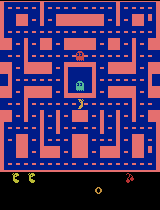

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


In [106]:
print("Evaluating the untrained network on five games. This can take a few minutes.", flush=True)
baseline = evaluate(model, EVAL_SEEDS, RUN_DIR / "demos" / "episode_0000.gif")
(RUN_DIR / "baseline.json").write_text(json.dumps(baseline, indent=2))
print("Before training:", baseline["scores"], "| mean:", baseline["mean"])
show_sample(RUN_DIR / "demos" / "episode_0000.gif", "Before training")

### 5d. learn during one game

Repeat **choose → play → remember → learn** until game over or the time limit. The counters span all games, so warm-up happens once. Every 1,000 decisions, copy the learning network into the target network.

In [107]:
def train_one_episode(train_env, episode):
    """Collect experience and update the agent during one complete game."""
    global total_steps, updates
    obs, _ = train_env.reset(seed=SEED + episode)
    score, losses = 0.0, []
    for step in range(MAX_STEPS):
        epsilon = 1.0 if total_steps < WARMUP_STEPS else EXPLORATION
        action = choose_action(model, obs, epsilon, train_rng, N_ACTIONS)
        next_obs, reward, ended, truncated, _ = train_env.step(action)
        replay.add(obs, action, reward, next_obs, ended, truncated)
        obs = next_obs
        score += reward
        total_steps += 1
        if total_steps >= WARMUP_STEPS and len(replay) >= BATCH_SIZE and total_steps % TRAIN_EVERY == 0:
            losses.append(learn(model, target, optimizer, replay.sample(BATCH_SIZE, replay_rng)))
            updates += 1
        if total_steps % TARGET_EVERY == 0:
            target.load_state_dict(model.state_dict())
        if total_steps % 500 == 0:
            elapsed = time.monotonic() - started
            print(f"  Episode {episode}/{EPISODES} | {total_steps:,} decisions | {updates:,} updates | {elapsed / 60:.1f} min", flush=True)
        if ended or truncated:
            break
    return {"episode": episode, "score": float(score), "steps": step + 1,
            "total_steps": total_steps, "exploration": epsilon,
            "mean_loss": float(np.mean(losses)) if losses else float("nan"),
            "elapsed_seconds": time.monotonic() - started,
            "terminated": bool(ended), "truncated": bool(truncated)}

### 5e. save a progress sample

Every 25 completed games, evaluate on a separate game, show the fast popup, and save a checkpoint. Evaluation does not add experiences to replay or change weights.

In [108]:
def save_progress_sample(episode):
    gif_path = RUN_DIR / "demos" / f"episode_{episode:04d}.gif"
    demo = evaluate(model, EVAL_SEEDS[:1], gif_path)
    demo_history.append({"episode": episode, **demo})
    (RUN_DIR / "demo_scores.json").write_text(json.dumps(demo_history, indent=2))
    print("Separate demonstration score:", demo["scores"][0])
    save_checkpoint(model, RUN_DIR / f"episode_{episode:04d}.pt", episode, total_steps)
    plot_training(history, RUN_DIR / "training_dashboard.png")
    show_sample(gif_path, f"After {episode} training games")

### 5f. save the current result

Run this helper on completion, interruption, or failure. Checkpoints include all weight updates so far; the CSV contains completed games only.

In [109]:
def save_training_result(status):
    save_checkpoint(model, RUN_DIR / "trained.pt", completed_episodes, total_steps)
    save_metrics(history, RUN_DIR / "training.csv")
    plot_training(history, RUN_DIR / "training_dashboard.png")
    summary = {"status": status, "completed_episodes": completed_episodes,
               "total_decisions": total_steps, "learning_updates": updates,
               "elapsed_seconds_including_periodic_demos": time.monotonic() - started}
    (RUN_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2))

### 5g. run the training games

This is the experiment loop. Each call plays one game and prints its score. **Interrupt / Stop** saves the current model; then continue to section 6. To start another experiment, rerun from 5a so the model, baseline, and results folder all reset together.

Episode 1/1000 | score 130 | recent mean 130.0 | exploration 100%
  Episode 2/1000 | 500 decisions | 0 updates | 0.0 min
  Episode 2/1000 | 1,000 decisions | 1 updates | 0.0 min
Episode 2/1000 | score 490 | recent mean 310.0 | exploration 9%
  Episode 3/1000 | 1,500 decisions | 126 updates | 0.1 min
Episode 3/1000 | score 400 | recent mean 340.0 | exploration 9%
  Episode 4/1000 | 2,000 decisions | 251 updates | 0.1 min
Episode 4/1000 | score 500 | recent mean 380.0 | exploration 9%
  Episode 5/1000 | 2,500 decisions | 376 updates | 0.1 min
Episode 5/1000 | score 210 | recent mean 346.0 | exploration 9%
  Episode 6/1000 | 3,000 decisions | 501 updates | 0.2 min
Episode 6/1000 | score 410 | recent mean 356.7 | exploration 9%
  Episode 7/1000 | 3,500 decisions | 626 updates | 0.2 min
Episode 7/1000 | score 430 | recent mean 367.1 | exploration 9%
  Episode 8/1000 | 4,000 decisions | 751 updates | 0.2 min
Episode 8/1000 | score 620 | recent mean 398.8 | exploration 9%
  Episode 9/1000 | 4

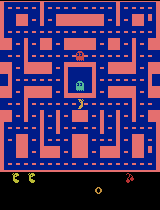

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 26/1000 | 14,000 decisions | 3,251 updates | 0.8 min
Episode 26/1000 | score 310 | recent mean 492.0 | exploration 9%
  Episode 27/1000 | 14,500 decisions | 3,376 updates | 0.9 min
Episode 27/1000 | score 470 | recent mean 491.2 | exploration 9%
  Episode 28/1000 | 15,000 decisions | 3,501 updates | 0.9 min
Episode 28/1000 | score 470 | recent mean 494.0 | exploration 9%
  Episode 29/1000 | 15,500 decisions | 3,626 updates | 0.9 min
Episode 29/1000 | score 480 | recent mean 493.2 | exploration 9%
  Episode 30/1000 | 16,000 decisions | 3,751 updates | 1.0 min
Episode 30/1000 | score 470 | recent mean 503.6 | exploration 9%
  Episode 31/1000 | 16,500 decisions | 3,876 updates | 1.0 min
Episode 31/1000 | score 460 | recent mean 505.6 | exploration 9%
  Episode 32/1000 | 17,000 decisions | 4,001 updates | 1.0 min
Episode 32/1000 | score 420 | recent mean 505.2 | exploration 9%
  Episode 33/1

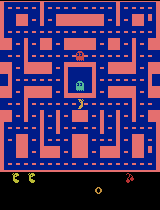

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 51/1000 | 29,500 decisions | 7,126 updates | 1.8 min
Episode 51/1000 | score 450 | recent mean 659.2 | exploration 9%
  Episode 52/1000 | 30,000 decisions | 7,251 updates | 1.9 min
Episode 52/1000 | score 520 | recent mean 661.2 | exploration 9%
Episode 53/1000 | score 290 | recent mean 654.0 | exploration 9%
  Episode 54/1000 | 30,500 decisions | 7,376 updates | 1.9 min
  Episode 54/1000 | 31,000 decisions | 7,501 updates | 1.9 min
Episode 54/1000 | score 620 | recent mean 659.6 | exploration 9%
  Episode 55/1000 | 31,500 decisions | 7,626 updates | 2.0 min
Episode 55/1000 | score 470 | recent mean 659.6 | exploration 9%
  Episode 56/1000 | 32,000 decisions | 7,751 updates | 2.0 min
Episode 56/1000 | score 1070 | recent mean 684.0 | exploration 9%
  Episode 57/1000 | 32,500 decisions | 7,876 updates | 2.0 min
Episode 57/1000 | score 430 | recent mean 684.4 | exploration 9%
  Episode 58/

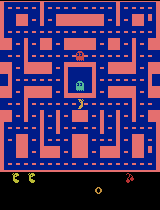

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 76/1000 | 44,500 decisions | 10,876 updates | 2.8 min
Episode 76/1000 | score 450 | recent mean 708.4 | exploration 9%
  Episode 77/1000 | 45,000 decisions | 11,001 updates | 2.8 min
Episode 77/1000 | score 880 | recent mean 722.8 | exploration 9%
  Episode 78/1000 | 45,500 decisions | 11,126 updates | 2.8 min
  Episode 78/1000 | 46,000 decisions | 11,251 updates | 2.9 min
Episode 78/1000 | score 1170 | recent mean 758.0 | exploration 9%
  Episode 79/1000 | 46,500 decisions | 11,376 updates | 2.9 min
  Episode 79/1000 | 47,000 decisions | 11,501 updates | 2.9 min
Episode 79/1000 | score 1290 | recent mean 784.8 | exploration 9%
  Episode 80/1000 | 47,500 decisions | 11,626 updates | 3.0 min
Episode 80/1000 | score 640 | recent mean 791.6 | exploration 9%
  Episode 81/1000 | 48,000 decisions | 11,751 updates | 3.0 min
Episode 81/1000 | score 460 | recent mean 767.2 | exploration 9%
  Epis

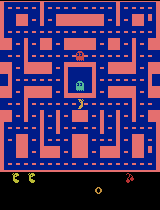

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 101/1000 | 59,500 decisions | 14,626 updates | 3.7 min
  Episode 101/1000 | 60,000 decisions | 14,751 updates | 3.8 min
Episode 101/1000 | score 800 | recent mean 683.6 | exploration 9%
  Episode 102/1000 | 60,500 decisions | 14,876 updates | 3.8 min
Episode 102/1000 | score 1020 | recent mean 689.2 | exploration 9%
  Episode 103/1000 | 61,000 decisions | 15,001 updates | 3.8 min
  Episode 103/1000 | 61,500 decisions | 15,126 updates | 3.9 min
Episode 103/1000 | score 890 | recent mean 678.0 | exploration 9%
  Episode 104/1000 | 62,000 decisions | 15,251 updates | 3.9 min
Episode 104/1000 | score 620 | recent mean 651.2 | exploration 9%
  Episode 105/1000 | 62,500 decisions | 15,376 updates | 3.9 min
Episode 105/1000 | score 290 | recent mean 637.2 | exploration 9%
  Episode 106/1000 | 63,000 decisions | 15,501 updates | 4.0 min
Episode 106/1000 | score 840 | recent mean 652.4 | explorat

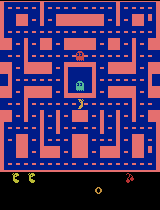

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 126/1000 | 76,000 decisions | 18,751 updates | 4.8 min
Episode 126/1000 | score 610 | recent mean 708.0 | exploration 9%
  Episode 127/1000 | 76,500 decisions | 18,876 updates | 4.8 min
  Episode 127/1000 | 77,000 decisions | 19,001 updates | 4.9 min
Episode 127/1000 | score 1100 | recent mean 711.2 | exploration 9%
  Episode 128/1000 | 77,500 decisions | 19,126 updates | 4.9 min
Episode 128/1000 | score 700 | recent mean 703.6 | exploration 9%
  Episode 129/1000 | 78,000 decisions | 19,251 updates | 4.9 min
Episode 129/1000 | score 1160 | recent mean 725.2 | exploration 9%
  Episode 130/1000 | 78,500 decisions | 19,376 updates | 4.9 min
Episode 130/1000 | score 590 | recent mean 737.2 | exploration 9%
  Episode 131/1000 | 79,000 decisions | 19,501 updates | 5.0 min
Episode 131/1000 | score 370 | recent mean 718.4 | exploration 9%
  Episode 132/1000 | 79,500 decisions | 19,626 updates | 

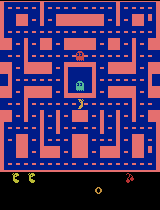

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 151/1000 | 90,000 decisions | 22,251 updates | 5.7 min
Episode 151/1000 | score 480 | recent mean 647.2 | exploration 9%
  Episode 152/1000 | 90,500 decisions | 22,376 updates | 5.7 min
Episode 152/1000 | score 470 | recent mean 622.0 | exploration 9%
  Episode 153/1000 | 91,000 decisions | 22,501 updates | 5.7 min
Episode 153/1000 | score 420 | recent mean 610.8 | exploration 9%
  Episode 154/1000 | 91,500 decisions | 22,626 updates | 5.8 min
Episode 154/1000 | score 1340 | recent mean 618.0 | exploration 9%
  Episode 155/1000 | 92,000 decisions | 22,751 updates | 5.8 min
  Episode 155/1000 | 92,500 decisions | 22,876 updates | 5.8 min
Episode 155/1000 | score 600 | recent mean 618.4 | exploration 9%
  Episode 156/1000 | 93,000 decisions | 23,001 updates | 5.9 min
Episode 156/1000 | score 750 | recent mean 633.6 | exploration 9%
  Episode 157/1000 | 93,500 decisions | 23,126 updates | 5

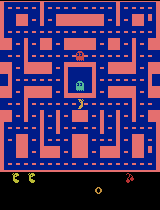

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 176/1000 | 103,500 decisions | 25,626 updates | 6.6 min
Episode 176/1000 | score 490 | recent mean 559.2 | exploration 9%
  Episode 177/1000 | 104,000 decisions | 25,751 updates | 6.6 min
Episode 177/1000 | score 340 | recent mean 554.0 | exploration 9%
  Episode 178/1000 | 104,500 decisions | 25,876 updates | 6.6 min
Episode 178/1000 | score 770 | recent mean 568.0 | exploration 9%
  Episode 179/1000 | 105,000 decisions | 26,001 updates | 6.6 min
  Episode 179/1000 | 105,500 decisions | 26,126 updates | 6.7 min
Episode 179/1000 | score 1200 | recent mean 562.4 | exploration 9%
  Episode 180/1000 | 106,000 decisions | 26,251 updates | 6.7 min
Episode 180/1000 | score 1610 | recent mean 602.8 | exploration 9%
  Episode 181/1000 | 106,500 decisions | 26,376 updates | 6.7 min
Episode 181/1000 | score 450 | recent mean 590.8 | exploration 9%
  Episode 182/1000 | 107,000 decisions | 26,501 up

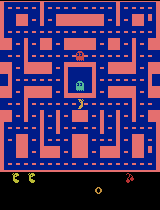

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
Episode 201/1000 | score 260 | recent mean 662.4 | exploration 9%
  Episode 202/1000 | 117,500 decisions | 29,126 updates | 7.4 min
Episode 202/1000 | score 600 | recent mean 672.8 | exploration 9%
  Episode 203/1000 | 118,000 decisions | 29,251 updates | 7.5 min
Episode 203/1000 | score 580 | recent mean 665.2 | exploration 9%
  Episode 204/1000 | 118,500 decisions | 29,376 updates | 7.5 min
  Episode 204/1000 | 119,000 decisions | 29,501 updates | 7.5 min
Episode 204/1000 | score 640 | recent mean 642.8 | exploration 9%
Episode 205/1000 | score 410 | recent mean 594.8 | exploration 9%
  Episode 206/1000 | 119,500 decisions | 29,626 updates | 7.6 min
  Episode 206/1000 | 120,000 decisions | 29,751 updates | 7.6 min
Episode 206/1000 | score 720 | recent mean 605.6 | exploration 9%
  Episode 207/1000 | 120,500 decisions | 29,876 updates | 7.6 min
Episode 207/1000 | score 380 | recent mean 586.4 | e

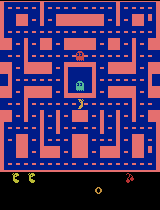

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 226/1000 | 131,000 decisions | 32,501 updates | 8.3 min
  Episode 226/1000 | 131,500 decisions | 32,626 updates | 8.3 min
Episode 226/1000 | score 1350 | recent mean 581.2 | exploration 9%
  Episode 227/1000 | 132,000 decisions | 32,751 updates | 8.4 min
Episode 227/1000 | score 350 | recent mean 571.2 | exploration 9%
  Episode 228/1000 | 132,500 decisions | 32,876 updates | 8.4 min
Episode 228/1000 | score 560 | recent mean 570.4 | exploration 9%
  Episode 229/1000 | 133,000 decisions | 33,001 updates | 8.4 min
Episode 229/1000 | score 640 | recent mean 570.4 | exploration 9%
  Episode 230/1000 | 133,500 decisions | 33,126 updates | 8.5 min
Episode 230/1000 | score 650 | recent mean 580.0 | exploration 9%
  Episode 231/1000 | 134,000 decisions | 33,251 updates | 8.5 min
Episode 231/1000 | score 670 | recent mean 578.0 | exploration 9%
  Episode 232/1000 | 134,500 decisions | 33,376 upd

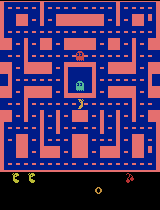

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 251/1000 | 145,000 decisions | 36,001 updates | 9.2 min
Episode 251/1000 | score 480 | recent mean 576.4 | exploration 9%
  Episode 252/1000 | 145,500 decisions | 36,126 updates | 9.2 min
  Episode 252/1000 | 146,000 decisions | 36,251 updates | 9.3 min
Episode 252/1000 | score 660 | recent mean 588.8 | exploration 9%
  Episode 253/1000 | 146,500 decisions | 36,376 updates | 9.3 min
Episode 253/1000 | score 470 | recent mean 585.2 | exploration 9%
  Episode 254/1000 | 147,000 decisions | 36,501 updates | 9.3 min
Episode 254/1000 | score 780 | recent mean 590.8 | exploration 9%
  Episode 255/1000 | 147,500 decisions | 36,626 updates | 9.3 min
Episode 255/1000 | score 330 | recent mean 578.0 | exploration 9%
  Episode 256/1000 | 148,000 decisions | 36,751 updates | 9.4 min
Episode 256/1000 | score 480 | recent mean 570.4 | exploration 9%
  Episode 257/1000 | 148,500 decisions | 36,876 upda

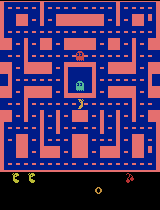

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 276/1000 | 158,500 decisions | 39,376 updates | 10.1 min
  Episode 276/1000 | 159,000 decisions | 39,501 updates | 10.1 min
Episode 276/1000 | score 510 | recent mean 546.4 | exploration 9%
  Episode 277/1000 | 159,500 decisions | 39,626 updates | 10.1 min
Episode 277/1000 | score 900 | recent mean 556.0 | exploration 9%
  Episode 278/1000 | 160,000 decisions | 39,751 updates | 10.1 min
Episode 278/1000 | score 370 | recent mean 552.0 | exploration 9%
  Episode 279/1000 | 160,500 decisions | 39,876 updates | 10.2 min
Episode 279/1000 | score 510 | recent mean 541.2 | exploration 9%
  Episode 280/1000 | 161,000 decisions | 40,001 updates | 10.2 min
Episode 280/1000 | score 600 | recent mean 552.0 | exploration 9%
  Episode 281/1000 | 161,500 decisions | 40,126 updates | 10.2 min
Episode 281/1000 | score 820 | recent mean 565.6 | exploration 9%
  Episode 282/1000 | 162,000 decisions | 40,2

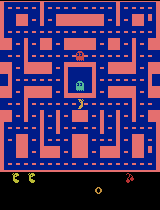

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 301/1000 | 172,500 decisions | 42,876 updates | 11.0 min
Episode 301/1000 | score 260 | recent mean 648.8 | exploration 9%
  Episode 302/1000 | 173,000 decisions | 43,001 updates | 11.0 min
Episode 302/1000 | score 550 | recent mean 634.8 | exploration 9%
  Episode 303/1000 | 173,500 decisions | 43,126 updates | 11.0 min
Episode 303/1000 | score 380 | recent mean 635.2 | exploration 9%
  Episode 304/1000 | 174,000 decisions | 43,251 updates | 11.0 min
Episode 304/1000 | score 520 | recent mean 635.6 | exploration 9%
  Episode 305/1000 | 174,500 decisions | 43,376 updates | 11.1 min
Episode 305/1000 | score 680 | recent mean 638.8 | exploration 9%
  Episode 306/1000 | 175,000 decisions | 43,501 updates | 11.1 min
  Episode 306/1000 | 175,500 decisions | 43,626 updates | 11.1 min
Episode 306/1000 | score 470 | recent mean 624.8 | exploration 9%
  Episode 307/1000 | 176,000 decisions | 43,7

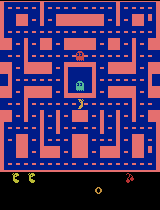

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 326/1000 | 187,000 decisions | 46,501 updates | 11.9 min
Episode 326/1000 | score 400 | recent mean 701.2 | exploration 9%
  Episode 327/1000 | 187,500 decisions | 46,626 updates | 11.9 min
Episode 327/1000 | score 380 | recent mean 694.4 | exploration 9%
  Episode 328/1000 | 188,000 decisions | 46,751 updates | 11.9 min
Episode 328/1000 | score 860 | recent mean 713.6 | exploration 9%
  Episode 329/1000 | 188,500 decisions | 46,876 updates | 12.0 min
Episode 329/1000 | score 470 | recent mean 711.6 | exploration 9%
  Episode 330/1000 | 189,000 decisions | 47,001 updates | 12.0 min
Episode 330/1000 | score 490 | recent mean 704.0 | exploration 9%
  Episode 331/1000 | 189,500 decisions | 47,126 updates | 12.0 min
Episode 331/1000 | score 510 | recent mean 705.6 | exploration 9%
  Episode 332/1000 | 190,000 decisions | 47,251 updates | 12.1 min
Episode 332/1000 | score 550 | recent mean 70

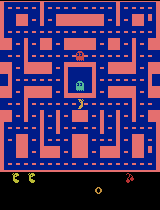

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 351/1000 | 201,000 decisions | 50,001 updates | 12.8 min
Episode 351/1000 | score 880 | recent mean 666.8 | exploration 9%
  Episode 352/1000 | 201,500 decisions | 50,126 updates | 12.8 min
Episode 352/1000 | score 520 | recent mean 672.4 | exploration 9%
  Episode 353/1000 | 202,000 decisions | 50,251 updates | 12.8 min
Episode 353/1000 | score 600 | recent mean 662.0 | exploration 9%
  Episode 354/1000 | 202,500 decisions | 50,376 updates | 12.9 min
  Episode 354/1000 | 203,000 decisions | 50,501 updates | 12.9 min
Episode 354/1000 | score 680 | recent mean 670.4 | exploration 9%
  Episode 355/1000 | 203,500 decisions | 50,626 updates | 12.9 min
Episode 355/1000 | score 820 | recent mean 683.6 | exploration 9%
Episode 356/1000 | score 660 | recent mean 689.6 | exploration 9%
  Episode 357/1000 | 204,000 decisions | 50,751 updates | 13.0 min
  Episode 357/1000 | 204,500 decisions | 50,8

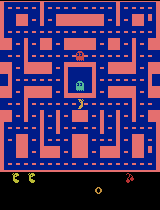

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 376/1000 | 214,500 decisions | 53,376 updates | 13.6 min
Episode 376/1000 | score 370 | recent mean 750.0 | exploration 9%
  Episode 377/1000 | 215,000 decisions | 53,501 updates | 13.7 min
Episode 377/1000 | score 430 | recent mean 746.4 | exploration 9%
  Episode 378/1000 | 215,500 decisions | 53,626 updates | 13.7 min
Episode 378/1000 | score 310 | recent mean 734.8 | exploration 9%
  Episode 379/1000 | 216,000 decisions | 53,751 updates | 13.7 min
Episode 379/1000 | score 440 | recent mean 725.2 | exploration 9%
  Episode 380/1000 | 216,500 decisions | 53,876 updates | 13.8 min
  Episode 380/1000 | 217,000 decisions | 54,001 updates | 13.8 min
Episode 380/1000 | score 1580 | recent mean 755.6 | exploration 9%
  Episode 381/1000 | 217,500 decisions | 54,126 updates | 13.8 min
Episode 381/1000 | score 620 | recent mean 754.0 | exploration 9%
  Episode 382/1000 | 218,000 decisions | 54,

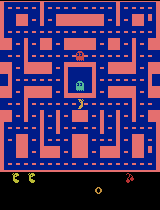

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 401/1000 | 228,500 decisions | 56,876 updates | 14.5 min
  Episode 401/1000 | 229,000 decisions | 57,001 updates | 14.6 min
Episode 401/1000 | score 950 | recent mean 650.0 | exploration 9%
  Episode 402/1000 | 229,500 decisions | 57,126 updates | 14.6 min
  Episode 402/1000 | 230,000 decisions | 57,251 updates | 14.6 min
Episode 402/1000 | score 1270 | recent mean 683.6 | exploration 9%
  Episode 403/1000 | 230,500 decisions | 57,376 updates | 14.6 min
Episode 403/1000 | score 400 | recent mean 687.2 | exploration 9%
  Episode 404/1000 | 231,000 decisions | 57,501 updates | 14.7 min
  Episode 404/1000 | 231,500 decisions | 57,626 updates | 14.7 min
Episode 404/1000 | score 1440 | recent mean 727.2 | exploration 9%
  Episode 405/1000 | 232,000 decisions | 57,751 updates | 14.7 min
Episode 405/1000 | score 1380 | recent mean 719.2 | exploration 9%
  Episode 406/1000 | 232,500 decisions | 

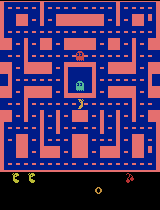

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 426/1000 | 245,500 decisions | 61,126 updates | 15.6 min
Episode 426/1000 | score 550 | recent mean 889.2 | exploration 9%
  Episode 427/1000 | 246,000 decisions | 61,251 updates | 15.6 min
  Episode 427/1000 | 246,500 decisions | 61,376 updates | 15.6 min
Episode 427/1000 | score 1770 | recent mean 909.2 | exploration 9%
  Episode 428/1000 | 247,000 decisions | 61,501 updates | 15.7 min
Episode 428/1000 | score 520 | recent mean 914.0 | exploration 9%
  Episode 429/1000 | 247,500 decisions | 61,626 updates | 15.7 min
Episode 429/1000 | score 310 | recent mean 868.8 | exploration 9%
  Episode 430/1000 | 248,000 decisions | 61,751 updates | 15.7 min
Episode 430/1000 | score 720 | recent mean 842.4 | exploration 9%
  Episode 431/1000 | 248,500 decisions | 61,876 updates | 15.8 min
Episode 431/1000 | score 290 | recent mean 834.0 | exploration 9%
  Episode 432/1000 | 249,000 decisions | 62,

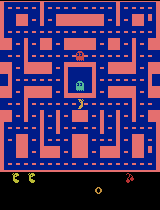

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 451/1000 | 261,500 decisions | 65,126 updates | 16.6 min
  Episode 451/1000 | 262,000 decisions | 65,251 updates | 16.6 min
Episode 451/1000 | score 1170 | recent mean 774.0 | exploration 9%
Episode 452/1000 | score 310 | recent mean 715.6 | exploration 9%
  Episode 453/1000 | 262,500 decisions | 65,376 updates | 16.7 min
  Episode 453/1000 | 263,000 decisions | 65,501 updates | 16.7 min
Episode 453/1000 | score 3960 | recent mean 853.2 | exploration 9%
  Episode 454/1000 | 263,500 decisions | 65,626 updates | 16.7 min
  Episode 454/1000 | 264,000 decisions | 65,751 updates | 16.8 min
Episode 454/1000 | score 1000 | recent mean 880.8 | exploration 9%
  Episode 455/1000 | 264,500 decisions | 65,876 updates | 16.8 min
Episode 455/1000 | score 610 | recent mean 876.4 | exploration 9%
  Episode 456/1000 | 265,000 decisions | 66,001 updates | 16.8 min
Episode 456/1000 | score 500 | recent mea

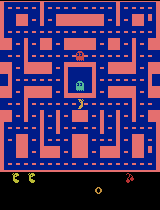

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 476/1000 | 276,500 decisions | 68,876 updates | 17.6 min
  Episode 476/1000 | 277,000 decisions | 69,001 updates | 17.6 min
Episode 476/1000 | score 1040 | recent mean 840.4 | exploration 9%
  Episode 477/1000 | 277,500 decisions | 69,126 updates | 17.6 min
Episode 477/1000 | score 310 | recent mean 840.4 | exploration 9%
  Episode 478/1000 | 278,000 decisions | 69,251 updates | 17.7 min
Episode 478/1000 | score 670 | recent mean 708.8 | exploration 9%
  Episode 479/1000 | 278,500 decisions | 69,376 updates | 17.7 min
Episode 479/1000 | score 520 | recent mean 689.6 | exploration 9%
  Episode 480/1000 | 279,000 decisions | 69,501 updates | 17.7 min
Episode 480/1000 | score 450 | recent mean 683.2 | exploration 9%
Episode 481/1000 | score 360 | recent mean 677.6 | exploration 9%
  Episode 482/1000 | 279,500 decisions | 69,626 updates | 17.7 min
Episode 482/1000 | score 560 | recent mean 6

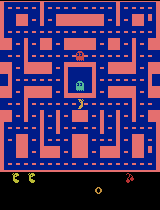

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 501/1000 | 290,500 decisions | 72,376 updates | 18.5 min
Episode 501/1000 | score 300 | recent mean 760.0 | exploration 9%
  Episode 502/1000 | 291,000 decisions | 72,501 updates | 18.5 min
Episode 502/1000 | score 860 | recent mean 782.0 | exploration 9%
  Episode 503/1000 | 291,500 decisions | 72,626 updates | 18.5 min
Episode 503/1000 | score 450 | recent mean 773.2 | exploration 9%
  Episode 504/1000 | 292,000 decisions | 72,751 updates | 18.6 min
Episode 504/1000 | score 500 | recent mean 772.4 | exploration 9%
  Episode 505/1000 | 292,500 decisions | 72,876 updates | 18.6 min
  Episode 505/1000 | 293,000 decisions | 73,001 updates | 18.6 min
Episode 505/1000 | score 960 | recent mean 792.8 | exploration 9%
  Episode 506/1000 | 293,500 decisions | 73,126 updates | 18.6 min
Episode 506/1000 | score 1210 | recent mean 826.8 | exploration 9%
  Episode 507/1000 | 294,000 decisions | 73,

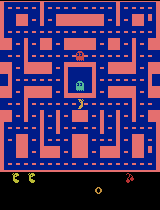

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 526/1000 | 306,000 decisions | 76,251 updates | 19.4 min
Episode 526/1000 | score 720 | recent mean 806.8 | exploration 9%
  Episode 527/1000 | 306,500 decisions | 76,376 updates | 19.5 min
  Episode 527/1000 | 307,000 decisions | 76,501 updates | 19.5 min
Episode 527/1000 | score 750 | recent mean 802.4 | exploration 9%
  Episode 528/1000 | 307,500 decisions | 76,626 updates | 19.5 min
Episode 528/1000 | score 500 | recent mean 804.4 | exploration 9%
  Episode 529/1000 | 308,000 decisions | 76,751 updates | 19.6 min
Episode 529/1000 | score 1090 | recent mean 828.0 | exploration 9%
  Episode 530/1000 | 308,500 decisions | 76,876 updates | 19.6 min
Episode 530/1000 | score 520 | recent mean 810.4 | exploration 9%
  Episode 531/1000 | 309,000 decisions | 77,001 updates | 19.6 min
Episode 531/1000 | score 660 | recent mean 788.4 | exploration 9%
  Episode 532/1000 | 309,500 decisions | 77,

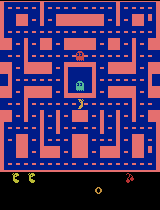

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 551/1000 | 321,500 decisions | 80,126 updates | 20.4 min
  Episode 551/1000 | 322,000 decisions | 80,251 updates | 20.5 min
Episode 551/1000 | score 1640 | recent mean 738.8 | exploration 9%
  Episode 552/1000 | 322,500 decisions | 80,376 updates | 20.5 min
Episode 552/1000 | score 2130 | recent mean 794.0 | exploration 9%
  Episode 553/1000 | 323,000 decisions | 80,501 updates | 20.5 min
Episode 553/1000 | score 770 | recent mean 804.8 | exploration 9%
  Episode 554/1000 | 323,500 decisions | 80,626 updates | 20.6 min
Episode 554/1000 | score 620 | recent mean 786.0 | exploration 9%
  Episode 555/1000 | 324,000 decisions | 80,751 updates | 20.6 min
  Episode 555/1000 | 324,500 decisions | 80,876 updates | 20.6 min
Episode 555/1000 | score 1020 | recent mean 806.0 | exploration 9%
  Episode 556/1000 | 325,000 decisions | 81,001 updates | 20.6 min
Episode 556/1000 | score 600 | recent mea

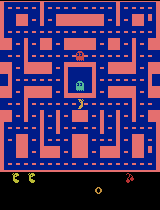

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 576/1000 | 337,000 decisions | 84,001 updates | 21.4 min
Episode 576/1000 | score 490 | recent mean 781.6 | exploration 9%
  Episode 577/1000 | 337,500 decisions | 84,126 updates | 21.4 min
Episode 577/1000 | score 560 | recent mean 718.8 | exploration 9%
  Episode 578/1000 | 338,000 decisions | 84,251 updates | 21.5 min
  Episode 578/1000 | 338,500 decisions | 84,376 updates | 21.5 min
Episode 578/1000 | score 2490 | recent mean 787.6 | exploration 9%
  Episode 579/1000 | 339,000 decisions | 84,501 updates | 21.5 min
Episode 579/1000 | score 400 | recent mean 778.8 | exploration 9%
  Episode 580/1000 | 339,500 decisions | 84,626 updates | 21.6 min
Episode 580/1000 | score 580 | recent mean 761.2 | exploration 9%
  Episode 581/1000 | 340,000 decisions | 84,751 updates | 21.6 min
Episode 581/1000 | score 290 | recent mean 748.8 | exploration 9%
  Episode 582/1000 | 340,500 decisions | 84,

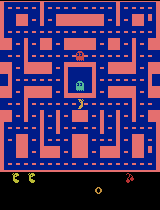

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 601/1000 | 352,000 decisions | 87,751 updates | 22.4 min
Episode 601/1000 | score 520 | recent mean 805.2 | exploration 9%
  Episode 602/1000 | 352,500 decisions | 87,876 updates | 22.4 min
Episode 602/1000 | score 900 | recent mean 818.8 | exploration 9%
  Episode 603/1000 | 353,000 decisions | 88,001 updates | 22.4 min
Episode 603/1000 | score 410 | recent mean 735.6 | exploration 9%
  Episode 604/1000 | 353,500 decisions | 88,126 updates | 22.5 min
  Episode 604/1000 | 354,000 decisions | 88,251 updates | 22.5 min
Episode 604/1000 | score 970 | recent mean 758.4 | exploration 9%
  Episode 605/1000 | 354,500 decisions | 88,376 updates | 22.5 min
Episode 605/1000 | score 790 | recent mean 766.8 | exploration 9%
  Episode 606/1000 | 355,000 decisions | 88,501 updates | 22.5 min
Episode 606/1000 | score 780 | recent mean 786.4 | exploration 9%
  Episode 607/1000 | 355,500 decisions | 88,6

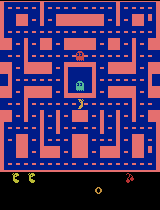

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 626/1000 | 368,000 decisions | 91,751 updates | 23.4 min
  Episode 626/1000 | 368,500 decisions | 91,876 updates | 23.4 min
Episode 626/1000 | score 1020 | recent mean 853.6 | exploration 9%
  Episode 627/1000 | 369,000 decisions | 92,001 updates | 23.4 min
Episode 627/1000 | score 520 | recent mean 838.4 | exploration 9%
  Episode 628/1000 | 369,500 decisions | 92,126 updates | 23.5 min
Episode 628/1000 | score 680 | recent mean 849.2 | exploration 9%
  Episode 629/1000 | 370,000 decisions | 92,251 updates | 23.5 min
  Episode 629/1000 | 370,500 decisions | 92,376 updates | 23.5 min
Episode 629/1000 | score 1610 | recent mean 874.8 | exploration 9%
  Episode 630/1000 | 371,000 decisions | 92,501 updates | 23.5 min
Episode 630/1000 | score 670 | recent mean 870.0 | exploration 9%
  Episode 631/1000 | 371,500 decisions | 92,626 updates | 23.6 min
Episode 631/1000 | score 710 | recent mean

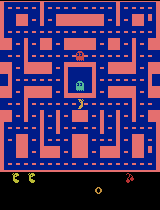

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 651/1000 | 385,000 decisions | 96,001 updates | 24.4 min
Episode 651/1000 | score 560 | recent mean 705.6 | exploration 9%
Episode 652/1000 | score 450 | recent mean 702.8 | exploration 9%
  Episode 653/1000 | 385,500 decisions | 96,126 updates | 24.5 min
Episode 653/1000 | score 330 | recent mean 688.8 | exploration 9%
  Episode 654/1000 | 386,000 decisions | 96,251 updates | 24.5 min
Episode 654/1000 | score 450 | recent mean 642.4 | exploration 9%
  Episode 655/1000 | 386,500 decisions | 96,376 updates | 24.5 min
Episode 655/1000 | score 480 | recent mean 634.8 | exploration 9%
  Episode 656/1000 | 387,000 decisions | 96,501 updates | 24.5 min
  Episode 656/1000 | 387,500 decisions | 96,626 updates | 24.6 min
Episode 656/1000 | score 530 | recent mean 627.6 | exploration 9%
Episode 657/1000 | score 180 | recent mean 619.6 | exploration 9%
  Episode 658/1000 | 388,000 decisions | 96,75

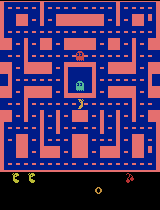

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 676/1000 | 399,500 decisions | 99,626 updates | 25.3 min
Episode 676/1000 | score 870 | recent mean 704.0 | exploration 9%
  Episode 677/1000 | 400,000 decisions | 99,751 updates | 25.4 min
  Episode 677/1000 | 400,500 decisions | 99,876 updates | 25.4 min
Episode 677/1000 | score 1370 | recent mean 740.8 | exploration 9%
  Episode 678/1000 | 401,000 decisions | 100,001 updates | 25.4 min
Episode 678/1000 | score 730 | recent mean 756.8 | exploration 9%
  Episode 679/1000 | 401,500 decisions | 100,126 updates | 25.5 min
Episode 679/1000 | score 300 | recent mean 750.8 | exploration 9%
  Episode 680/1000 | 402,000 decisions | 100,251 updates | 25.5 min
Episode 680/1000 | score 880 | recent mean 766.8 | exploration 9%
  Episode 681/1000 | 402,500 decisions | 100,376 updates | 25.5 min
  Episode 681/1000 | 403,000 decisions | 100,501 updates | 25.6 min
Episode 681/1000 | score 960 | recent 

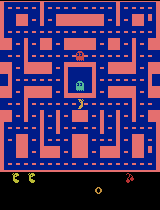

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 701/1000 | 415,000 decisions | 103,501 updates | 26.3 min
Episode 701/1000 | score 1380 | recent mean 812.0 | exploration 9%
  Episode 702/1000 | 415,500 decisions | 103,626 updates | 26.4 min
  Episode 702/1000 | 416,000 decisions | 103,751 updates | 26.4 min
Episode 702/1000 | score 710 | recent mean 785.6 | exploration 9%
  Episode 703/1000 | 416,500 decisions | 103,876 updates | 26.4 min
Episode 703/1000 | score 850 | recent mean 790.4 | exploration 9%
  Episode 704/1000 | 417,000 decisions | 104,001 updates | 26.5 min
Episode 704/1000 | score 720 | recent mean 807.2 | exploration 9%
  Episode 705/1000 | 417,500 decisions | 104,126 updates | 26.5 min
Episode 705/1000 | score 420 | recent mean 788.8 | exploration 9%
  Episode 706/1000 | 418,000 decisions | 104,251 updates | 26.5 min
  Episode 706/1000 | 418,500 decisions | 104,376 updates | 26.5 min
Episode 706/1000 | score 920 | rece

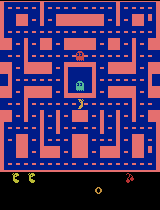

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 726/1000 | 431,500 decisions | 107,626 updates | 27.4 min
Episode 726/1000 | score 410 | recent mean 865.6 | exploration 9%
  Episode 727/1000 | 432,000 decisions | 107,751 updates | 27.4 min
Episode 727/1000 | score 380 | recent mean 852.4 | exploration 9%
  Episode 728/1000 | 432,500 decisions | 107,876 updates | 27.4 min
Episode 728/1000 | score 450 | recent mean 836.4 | exploration 9%
  Episode 729/1000 | 433,000 decisions | 108,001 updates | 27.5 min
Episode 729/1000 | score 400 | recent mean 823.6 | exploration 9%
  Episode 730/1000 | 433,500 decisions | 108,126 updates | 27.5 min
Episode 730/1000 | score 590 | recent mean 830.4 | exploration 9%
  Episode 731/1000 | 434,000 decisions | 108,251 updates | 27.5 min
Episode 731/1000 | score 1370 | recent mean 848.4 | exploration 9%
  Episode 732/1000 | 434,500 decisions | 108,376 updates | 27.6 min
Episode 732/1000 | score 900 | recent

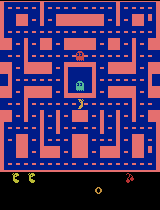

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 751/1000 | 447,000 decisions | 111,501 updates | 28.4 min
Episode 751/1000 | score 610 | recent mean 783.6 | exploration 9%
  Episode 752/1000 | 447,500 decisions | 111,626 updates | 28.4 min
Episode 752/1000 | score 1280 | recent mean 819.6 | exploration 9%
  Episode 753/1000 | 448,000 decisions | 111,751 updates | 28.4 min
Episode 753/1000 | score 1300 | recent mean 853.6 | exploration 9%
  Episode 754/1000 | 448,500 decisions | 111,876 updates | 28.4 min
  Episode 754/1000 | 449,000 decisions | 112,001 updates | 28.5 min
Episode 754/1000 | score 1440 | recent mean 895.2 | exploration 9%
  Episode 755/1000 | 449,500 decisions | 112,126 updates | 28.5 min
  Episode 755/1000 | 450,000 decisions | 112,251 updates | 28.5 min
Episode 755/1000 | score 1440 | recent mean 929.2 | exploration 9%
  Episode 756/1000 | 450,500 decisions | 112,376 updates | 28.6 min
Episode 756/1000 | score 800 | r

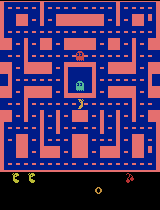

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 776/1000 | 462,000 decisions | 115,251 updates | 29.3 min
Episode 776/1000 | score 360 | recent mean 778.4 | exploration 9%
  Episode 777/1000 | 462,500 decisions | 115,376 updates | 29.3 min
  Episode 777/1000 | 463,000 decisions | 115,501 updates | 29.4 min
Episode 777/1000 | score 970 | recent mean 766.0 | exploration 9%
  Episode 778/1000 | 463,500 decisions | 115,626 updates | 29.4 min
Episode 778/1000 | score 820 | recent mean 746.8 | exploration 9%
  Episode 779/1000 | 464,000 decisions | 115,751 updates | 29.4 min
Episode 779/1000 | score 670 | recent mean 716.0 | exploration 9%
  Episode 780/1000 | 464,500 decisions | 115,876 updates | 29.5 min
Episode 780/1000 | score 430 | recent mean 675.6 | exploration 9%
  Episode 781/1000 | 465,000 decisions | 116,001 updates | 29.5 min
Episode 781/1000 | score 870 | recent mean 678.4 | exploration 9%
  Episode 782/1000 | 465,500 decisions

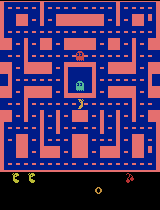

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 801/1000 | 477,000 decisions | 119,001 updates | 30.3 min
  Episode 801/1000 | 477,500 decisions | 119,126 updates | 30.3 min
Episode 801/1000 | score 740 | recent mean 866.0 | exploration 9%
  Episode 802/1000 | 478,000 decisions | 119,251 updates | 30.3 min
Episode 802/1000 | score 2060 | recent mean 909.6 | exploration 9%
  Episode 803/1000 | 478,500 decisions | 119,376 updates | 30.3 min
Episode 803/1000 | score 1470 | recent mean 935.6 | exploration 9%
  Episode 804/1000 | 479,000 decisions | 119,501 updates | 30.4 min
Episode 804/1000 | score 630 | recent mean 934.0 | exploration 9%
  Episode 805/1000 | 479,500 decisions | 119,626 updates | 30.4 min
  Episode 805/1000 | 480,000 decisions | 119,751 updates | 30.4 min
Episode 805/1000 | score 1530 | recent mean 978.0 | exploration 9%
  Episode 806/1000 | 480,500 decisions | 119,876 updates | 30.5 min
  Episode 806/1000 | 481,000 deci

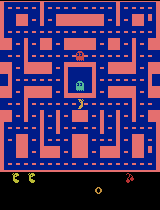

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 826/1000 | 492,000 decisions | 122,751 updates | 31.2 min
  Episode 826/1000 | 492,500 decisions | 122,876 updates | 31.2 min
Episode 826/1000 | score 1290 | recent mean 752.4 | exploration 9%
  Episode 827/1000 | 493,000 decisions | 123,001 updates | 31.3 min
Episode 827/1000 | score 800 | recent mean 702.0 | exploration 9%
  Episode 828/1000 | 493,500 decisions | 123,126 updates | 31.3 min
Episode 828/1000 | score 760 | recent mean 673.6 | exploration 9%
  Episode 829/1000 | 494,000 decisions | 123,251 updates | 31.3 min
  Episode 829/1000 | 494,500 decisions | 123,376 updates | 31.4 min
Episode 829/1000 | score 1310 | recent mean 700.8 | exploration 9%
  Episode 830/1000 | 495,000 decisions | 123,501 updates | 31.4 min
Episode 830/1000 | score 840 | recent mean 673.2 | exploration 9%
  Episode 831/1000 | 495,500 decisions | 123,626 updates | 31.4 min
  Episode 831/1000 | 496,000 decis

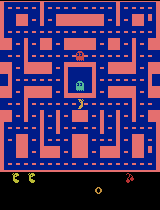

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 851/1000 | 506,000 decisions | 126,251 updates | 32.1 min
  Episode 851/1000 | 506,500 decisions | 126,376 updates | 32.1 min
Episode 851/1000 | score 1070 | recent mean 696.0 | exploration 9%
  Episode 852/1000 | 507,000 decisions | 126,501 updates | 32.2 min
Episode 852/1000 | score 760 | recent mean 694.4 | exploration 9%
  Episode 853/1000 | 507,500 decisions | 126,626 updates | 32.2 min
  Episode 853/1000 | 508,000 decisions | 126,751 updates | 32.2 min
Episode 853/1000 | score 1350 | recent mean 718.0 | exploration 9%
Episode 854/1000 | score 380 | recent mean 680.8 | exploration 9%
  Episode 855/1000 | 508,500 decisions | 126,876 updates | 32.3 min
  Episode 855/1000 | 509,000 decisions | 127,001 updates | 32.3 min
Episode 855/1000 | score 800 | recent mean 679.2 | exploration 9%
  Episode 856/1000 | 509,500 decisions | 127,126 updates | 32.3 min
Episode 856/1000 | score 270 | rec

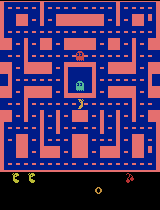

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 876/1000 | 520,500 decisions | 129,876 updates | 33.1 min
Episode 876/1000 | score 710 | recent mean 705.6 | exploration 9%
  Episode 877/1000 | 521,000 decisions | 130,001 updates | 33.1 min
Episode 877/1000 | score 400 | recent mean 691.2 | exploration 9%
  Episode 878/1000 | 521,500 decisions | 130,126 updates | 33.1 min
Episode 878/1000 | score 660 | recent mean 663.6 | exploration 9%
  Episode 879/1000 | 522,000 decisions | 130,251 updates | 33.2 min
Episode 879/1000 | score 360 | recent mean 662.8 | exploration 9%
  Episode 880/1000 | 522,500 decisions | 130,376 updates | 33.2 min
Episode 880/1000 | score 540 | recent mean 652.4 | exploration 9%
  Episode 881/1000 | 523,000 decisions | 130,501 updates | 33.2 min
Episode 881/1000 | score 490 | recent mean 661.2 | exploration 9%
  Episode 882/1000 | 523,500 decisions | 130,626 updates | 33.2 min
Episode 882/1000 | score 450 | recent 

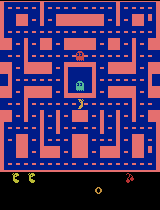

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 901/1000 | 534,000 decisions | 133,251 updates | 33.9 min
  Episode 901/1000 | 534,500 decisions | 133,376 updates | 34.0 min
Episode 901/1000 | score 1160 | recent mean 647.2 | exploration 9%
  Episode 902/1000 | 535,000 decisions | 133,501 updates | 34.0 min
Episode 902/1000 | score 360 | recent mean 645.6 | exploration 9%
  Episode 903/1000 | 535,500 decisions | 133,626 updates | 34.0 min
Episode 903/1000 | score 610 | recent mean 643.6 | exploration 9%
  Episode 904/1000 | 536,000 decisions | 133,751 updates | 34.0 min
Episode 904/1000 | score 750 | recent mean 659.2 | exploration 9%
  Episode 905/1000 | 536,500 decisions | 133,876 updates | 34.1 min
Episode 905/1000 | score 530 | recent mean 658.8 | exploration 9%
  Episode 906/1000 | 537,000 decisions | 134,001 updates | 34.1 min
Episode 906/1000 | score 500 | recent mean 659.2 | exploration 9%
  Episode 907/1000 | 537,500 decision

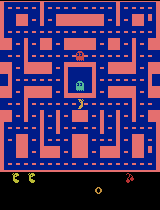

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
Episode 926/1000 | score 500 | recent mean 705.2 | exploration 9%
  Episode 927/1000 | 549,500 decisions | 137,126 updates | 34.9 min
Episode 927/1000 | score 420 | recent mean 707.6 | exploration 9%
  Episode 928/1000 | 550,000 decisions | 137,251 updates | 34.9 min
  Episode 928/1000 | 550,500 decisions | 137,376 updates | 34.9 min
Episode 928/1000 | score 1090 | recent mean 726.8 | exploration 9%
  Episode 929/1000 | 551,000 decisions | 137,501 updates | 35.0 min
Episode 929/1000 | score 550 | recent mean 718.8 | exploration 9%
  Episode 930/1000 | 551,500 decisions | 137,626 updates | 35.0 min
  Episode 930/1000 | 552,000 decisions | 137,751 updates | 35.0 min
Episode 930/1000 | score 1210 | recent mean 746.0 | exploration 9%
  Episode 931/1000 | 552,500 decisions | 137,876 updates | 35.1 min
Episode 931/1000 | score 660 | recent mean 752.4 | exploration 9%
  Episode 932/1000 | 553,000 decisio

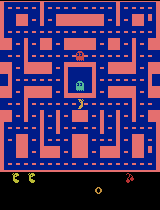

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 951/1000 | 564,500 decisions | 140,876 updates | 35.8 min
Episode 951/1000 | score 560 | recent mean 789.6 | exploration 9%
  Episode 952/1000 | 565,000 decisions | 141,001 updates | 35.9 min
Episode 952/1000 | score 930 | recent mean 810.0 | exploration 9%
  Episode 953/1000 | 565,500 decisions | 141,126 updates | 35.9 min
  Episode 953/1000 | 566,000 decisions | 141,251 updates | 35.9 min
Episode 953/1000 | score 700 | recent mean 794.4 | exploration 9%
  Episode 954/1000 | 566,500 decisions | 141,376 updates | 35.9 min
Episode 954/1000 | score 530 | recent mean 793.6 | exploration 9%
  Episode 955/1000 | 567,000 decisions | 141,501 updates | 36.0 min
Episode 955/1000 | score 820 | recent mean 778.0 | exploration 9%
  Episode 956/1000 | 567,500 decisions | 141,626 updates | 36.0 min
  Episode 956/1000 | 568,000 decisions | 141,751 updates | 36.0 min
Episode 956/1000 | score 1140 | rece

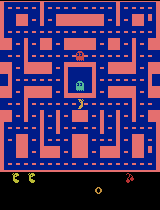

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 976/1000 | 580,500 decisions | 144,876 updates | 36.8 min
Episode 976/1000 | score 400 | recent mean 852.8 | exploration 9%
  Episode 977/1000 | 581,000 decisions | 145,001 updates | 36.9 min
Episode 977/1000 | score 550 | recent mean 837.6 | exploration 9%
  Episode 978/1000 | 581,500 decisions | 145,126 updates | 36.9 min
Episode 978/1000 | score 440 | recent mean 827.2 | exploration 9%
  Episode 979/1000 | 582,000 decisions | 145,251 updates | 36.9 min
Episode 979/1000 | score 1210 | recent mean 854.4 | exploration 9%
  Episode 980/1000 | 582,500 decisions | 145,376 updates | 37.0 min
  Episode 980/1000 | 583,000 decisions | 145,501 updates | 37.0 min
Episode 980/1000 | score 590 | recent mean 845.2 | exploration 9%
  Episode 981/1000 | 583,500 decisions | 145,626 updates | 37.0 min
Episode 981/1000 | score 400 | recent mean 815.6 | exploration 9%
  Episode 982/1000 | 584,000 decision

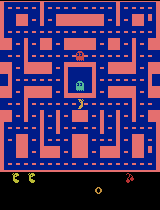

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
Saved: pacman_runs/20260915_231634_675837


In [110]:
if _training_started:
    raise RuntimeError("Start a new experiment by rerunning from section 5a, or use Run All.")
_training_started = True
train_env = make_env()
started = time.monotonic()
status = "completed"
try:
    for episode in range(1, EPISODES + 1):
        row = train_one_episode(train_env, episode)
        history.append(row)
        completed_episodes = episode
        recent_mean = np.mean([game["score"] for game in history[-25:]])
        print(f"Episode {episode}/{EPISODES} | score {row['score']:.0f} | "
              f"recent mean {recent_mean:.1f} | exploration {row['exploration']:.0%}", flush=True)
        save_metrics(history, RUN_DIR / "training.csv")
        if episode % DEMO_EVERY == 0:
            save_progress_sample(episode)
except KeyboardInterrupt:
    status = "interrupted"
    print("Stopped early. Saving your agent; continue to section 6 for results.")
except Exception:
    status = "failed"
    raise
finally:
    train_env.close()
    save_training_result(status)
print("Saved:", RUN_DIR)
if updates == 0:
    print("No learning updates yet: this run ended before a training batch was ready.")

## 6. did it learn?

Compare all five games under the same settings. The highlighted GIF is the best of these five trained games;
it is an illustration, not the evidence by itself. Five games give a small comparison, not a reliable research estimate.

### 6a. play the saved agent

Reload the checkpoint and play the same five evaluation seeds. This tests both the saved file and the agent’s behavior.

In [111]:
# Load the saved model so the evaluation also verifies checkpoint playback.
checkpoint = torch.load(RUN_DIR / "trained.pt", map_location="cpu", weights_only=True)
trained_model = DQN(checkpoint["n_actions"]).to(DEVICE)
trained_model.load_state_dict(checkpoint["model"])
print("Evaluating the saved trained network on the same five games...", flush=True)
after = evaluate(trained_model, EVAL_SEEDS, RUN_DIR / "demos" / "final_best.gif", record_best=True)

Evaluating the saved trained network on the same five games...


### 6b. compare all five scores

Positive change means a higher average in this small test. A short run can get worse, and one good-looking sample is not enough to claim improvement.

  Game     Before      After
     1        350        970
     2        500        560
     3        320        810
     4        800       2150
     5        490        870
  Mean      492.0     1072.0
Change in mean score: +580.0
Time-limited games before / after: 0 / 0


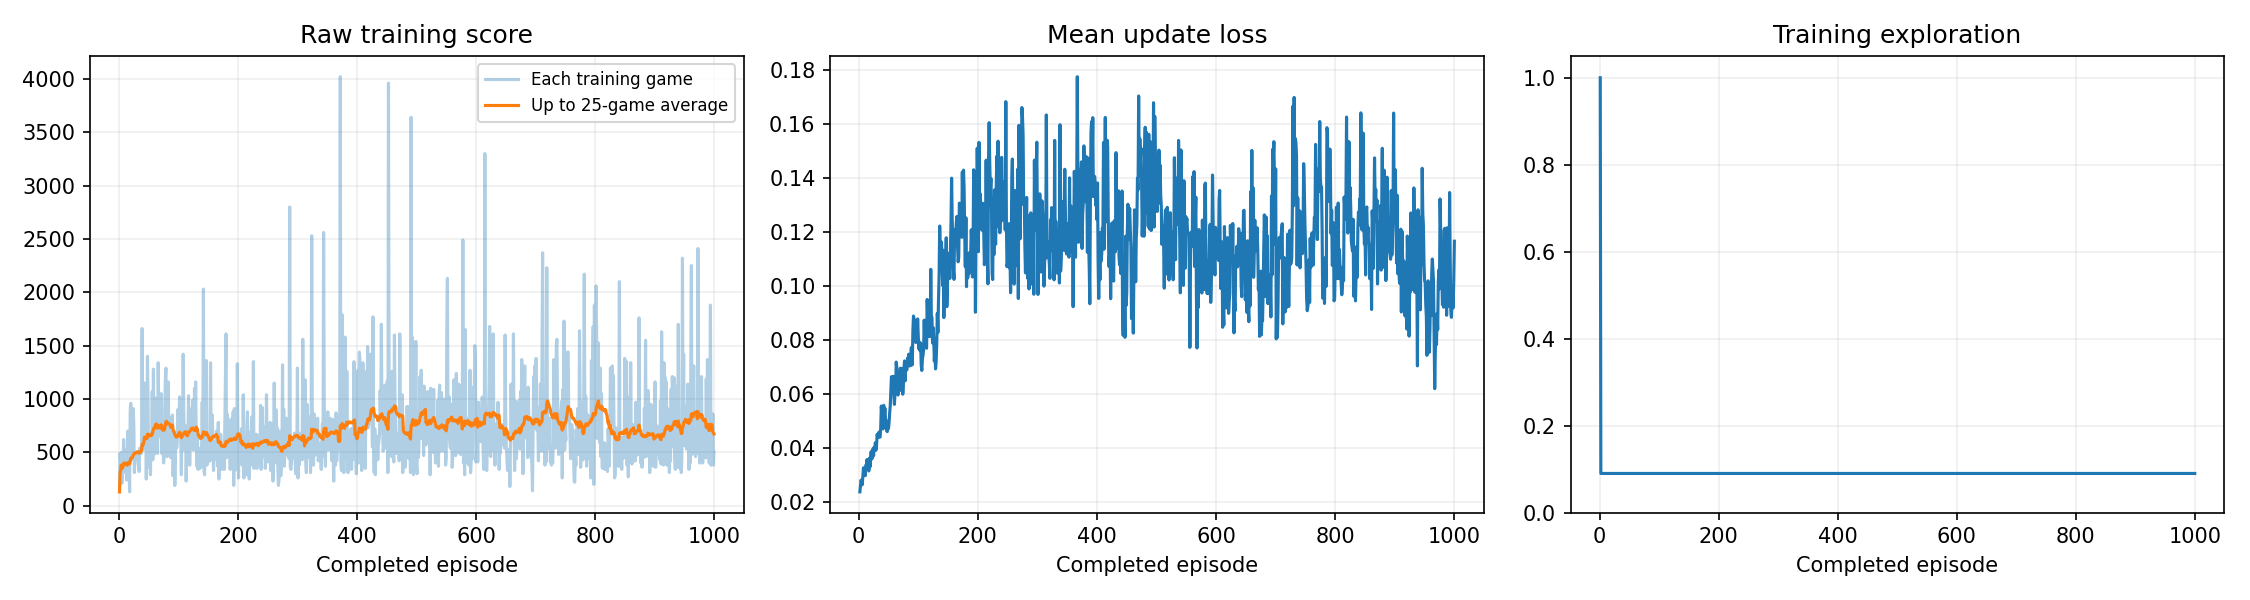

Final saved agent | 4× playback | 2 plays | first 20s of game time


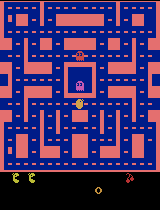

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'


In [112]:
comparison = {"baseline_kind": "untrained network", "before": baseline, "after": after,
              "evaluation_exploration": EVAL_EXPLORATION, "max_decisions_per_game": MAX_STEPS}
(RUN_DIR / "comparison.json").write_text(json.dumps(comparison, indent=2))
print(f"{'Game':>6} {'Before':>10} {'After':>10}")
for game, (before_score, after_score) in enumerate(zip(baseline["scores"], after["scores"]), 1):
    print(f"{game:>6} {before_score:>10.0f} {after_score:>10.0f}")
print(f"{'Mean':>6} {baseline['mean']:>10.1f} {after['mean']:>10.1f}")
print(f"Change in mean score: {after['mean'] - baseline['mean']:+.1f}")
print("Time-limited games before / after:", sum(baseline["time_limited"]), "/", sum(after["time_limited"]))
display(Image(filename=str(RUN_DIR / "training_dashboard.png")))
show_sample(RUN_DIR / "demos" / "final_best.gif", "Final saved agent")

## 7. save and explain your experiment

The next cell creates a ZIP containing your settings, package versions, all evaluation scores, training log,
plot, GIFs, and playback checkpoints. In Colab, download it before ending the session.
To try another setting, change the three choices and run all cells again; that starts from scratch.

Keep the notebook, plot, selected GIFs, comparison, and your explanation in your GitHub submission.
Model checkpoints can make repositories large; keep them locally or attach them to a GitHub release.

In [113]:
archive = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
try:
    from google.colab import files
except ImportError:
    display(FileLink(archive, result_html_prefix="Download your experiment: "))
else:
    files.download(archive)
print("Results folder:", RUN_DIR.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Results folder: /content/pacman_runs/20260915_231634_675837


### your explanation

- **My choices:** exploration = __, episodes = __, learning rate = __.
- **My prediction:** I expected these settings to __ because __.
- **What happened:** mean score before = __; after = __. In the gameplay, I noticed __.
- **One limitation:** __.
- **My next experiment:** change only __ to __ and keep the other two settings fixed.

The agent observes four screens, chooses a joystick action, and receives game rewards.
Lower training loss does not necessarily mean a higher game score. Report lack of progress if that is what happened.

### implementation notes and sources

This is a small, readable DQN experiment, not a reproduction of a large Atari benchmark.
Replay is deliberately small for laptops. Epsilon stays constant after warm-up. Checkpoints support playback;
rerunning starts a new experiment, rather than resuming the optimizer, replay memory, or an interrupted game.
GPU results can vary even with fixed seeds.

- [ALE installation and Gymnasium registration](https://ale.farama.org/getting-started/)
- [Gymnasium Atari preprocessing](https://gymnasium.farama.org/api/wrappers/misc_wrappers/#gymnasium.wrappers.AtariPreprocessing)
- [Gymnasium frame stacking](https://gymnasium.farama.org/api/wrappers/observation_wrappers/#gymnasium.wrappers.FrameStackObservation)
- [DQN paper: Human-level control through deep reinforcement learning](https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf)